<a href="https://colab.research.google.com/github/225K3125/computer_vision_oscar/blob/main/notebooks/UA2_AA2%20-%20Ejercicio%20Completo%20de%20T%C3%A9cnicas%20Cl%C3%A1sicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica — Técnicas clásicas de procesamiento y análisis de imágenes con OpenCV

**Módulo:** Computer Vision  
**Objetivo:** practicar técnicas clásicas de análisis y procesamiento de imágenes usando OpenCV.

En esta práctica trabajaremos con imágenes de ejemplo incluidas en `skimage.data`, por lo que no es necesario descargar imágenes externas.

## Técnicas incluidas

- Histogramas.
- Brillo y contraste.
- Ecualización normal y adaptativa.
- Convoluciones: media, mediana, paso alto, Sobel y Laplace.
- Umbralización simple, Otsu y adaptativa.
- Detección: componentes conexas, algoritmo de dos pasadas y bounding boxes.
- Filtrado morfológico: erosión, dilatación, apertura, cierre, hit and miss, extracción de fronteras y filtros min/max.


## 0. Instalación de librerías

Ejecuta esta celda si estás en un entorno donde falte alguna librería.


In [1]:
%matplotlib inline

In [ ]:
# Descomenta si necesitas instalar dependencias
!pip install opencv-python scikit-image matplotlib numpy


## 1. Importación de librerías y funciones auxiliares

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.util import img_as_ubyte

plt.rcParams["figure.figsize"] = (6, 6)

def show(img, title="", cmap=None, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title="", figsize=(5, 5)):
    show(img, title, cmap="gray", figsize=figsize)

def plot_histogram(gray, title="Histograma"):
    plt.figure(figsize=(8, 4))
    plt.hist(gray.ravel(), bins=256, range=(0, 255))
    plt.title(title)
    plt.xlabel("Intensidad")
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.2)
    plt.show()

def compare_images(images_dict, cmap="gray", figsize=(15, 5)):
    n = len(images_dict)
    plt.figure(figsize=figsize)
    for i, (title, img) in enumerate(images_dict.items(), start=1):
        plt.subplot(1, n, i)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


## 2. Dataset de imágenes

Usaremos cinco imágenes con características distintas:

| Imagen | Uso principal |
|---|---|
| `camera` | histograma, contraste y bordes |
| `moon` | bajo contraste y ecualización |
| `coins` | segmentación, componentes conexas y bounding boxes |
| `page` | umbralización simple, Otsu y adaptativa |
| `astronaut` | imagen en color, brillo/contraste y conversión a gris |


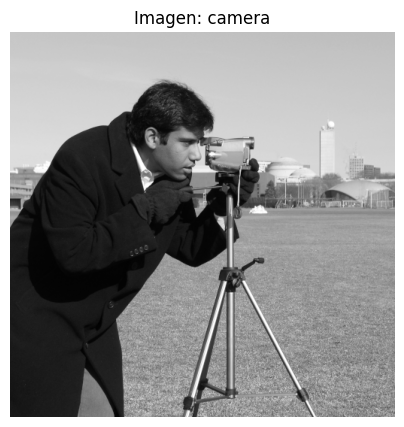

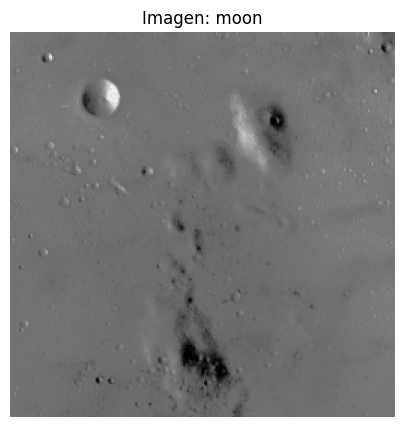

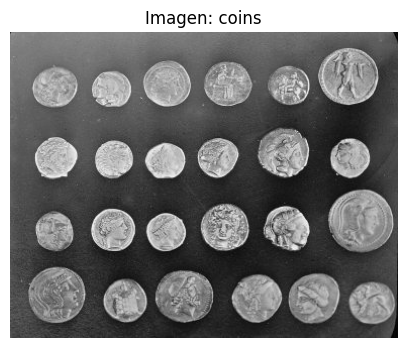

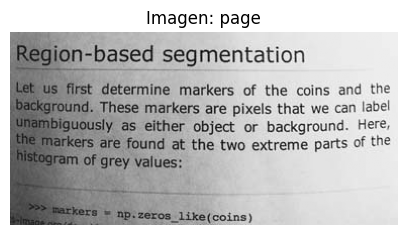

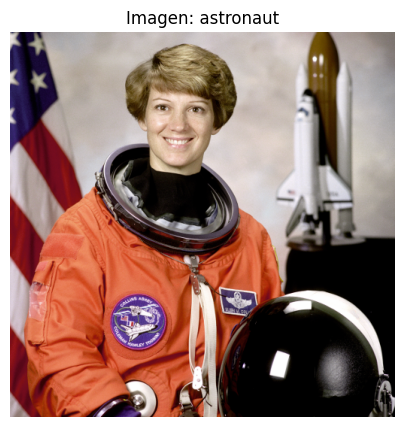

In [4]:
# Cargar imágenes de skimage
images = {
    "camera": img_as_ubyte(data.camera()),
    "moon": img_as_ubyte(data.moon()),
    "coins": img_as_ubyte(data.coins()),
    "page": img_as_ubyte(data.page()),
    "astronaut": img_as_ubyte(data.astronaut())
}

# Mostrar imágenes
for name, img in images.items():
    if img.ndim == 2:
        show_gray(img, f"Imagen: {name}")
    else:
        show(img, f"Imagen: {name}")


# Ejercicio 1 — Histogramas

## Enunciado

Analiza el histograma de las imágenes `camera`, `moon`, `coins` y `page`.

## Se pide

1. Mostrar cada imagen.
2. Calcular su histograma.
3. Interpretar si la imagen tiene bajo contraste, alto contraste, zonas oscuras, zonas claras, histograma concentrado o extendido.

## Preguntas

1. ¿Qué imagen tiene el histograma más concentrado?
2. ¿Cuál tiene mejor rango dinámico?
3. ¿Qué imagen parece más adecuada para aplicar ecualización?


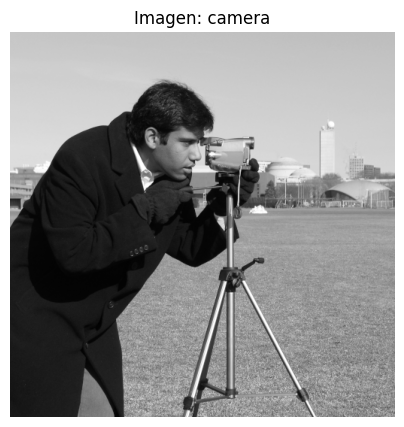

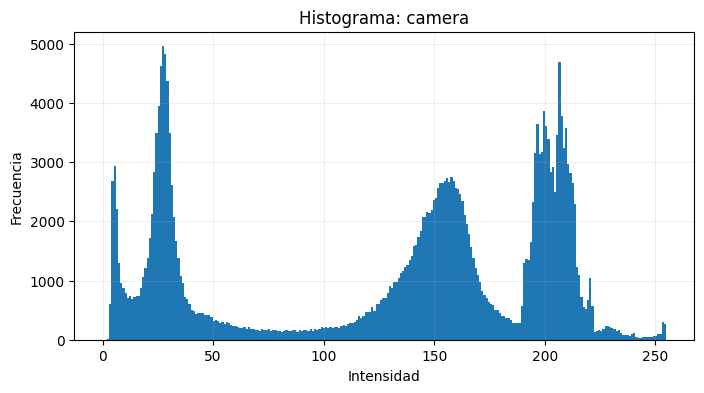

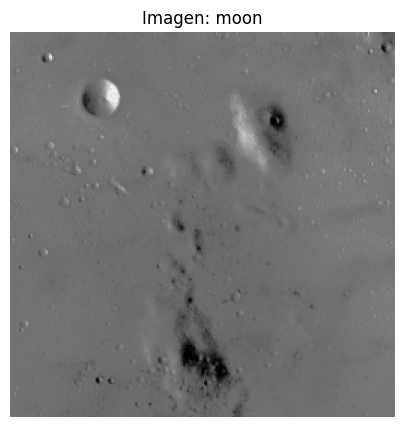

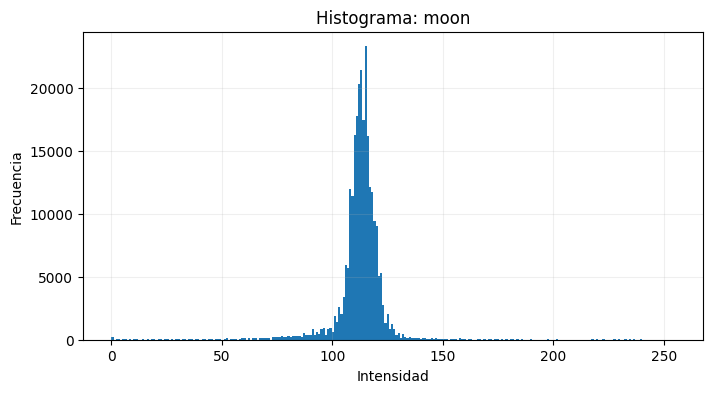

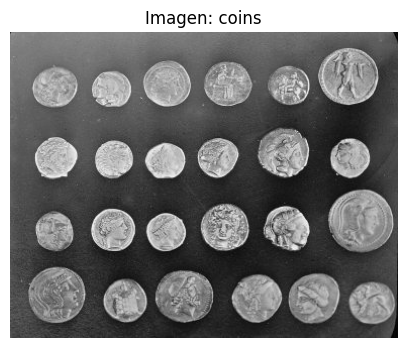

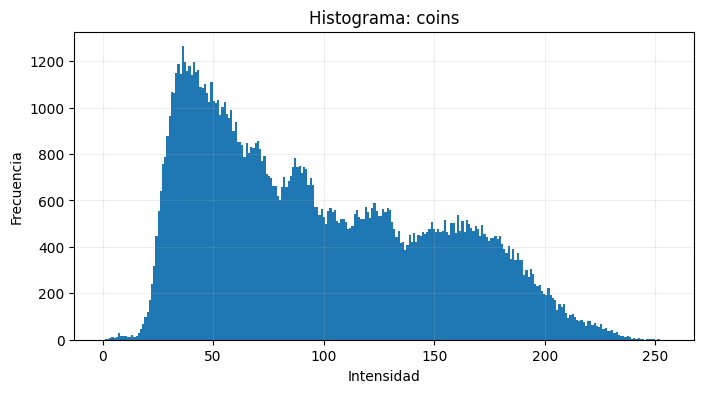

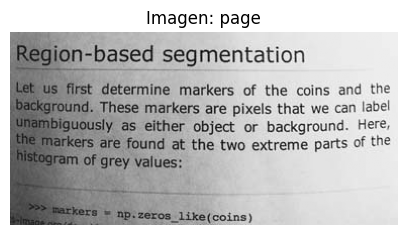

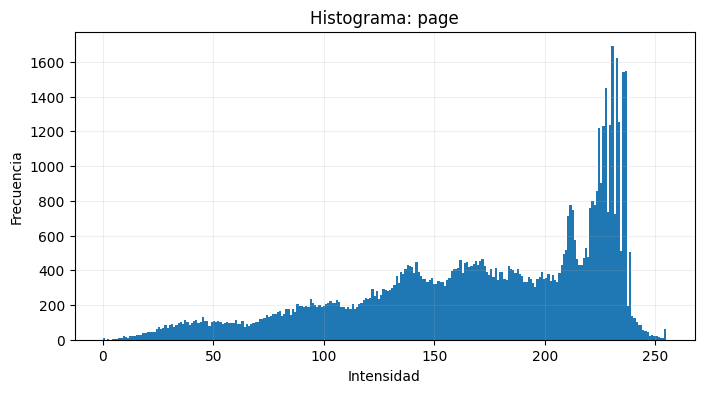

In [ ]:
for name in ["camera", "moon", "coins", "page"]:
    img = images[name]
    show_gray(img, f"Imagen: {name}")
    plot_histogram(img, f"Histograma: {name}")


### Respuesta del alumno

- Imagen con menor contraste: Moon
- Imagen con mayor rango dinámico: Cammera
- Imagen más adecuada para ecualización: Moon
- Justificación: Segun mi analisis una imagen de bajo contraste tiene muy agrupada la intensidad, la imagen con mayor rango dinamico es aquella que se mueve en todo el espectro x la que mas lo usa en plenitud en este caso. La imagen con ayor agrupación es la mas ecualizable.


# Ejercicio 2 — Brillo y contraste

## Enunciado

Modifica brillo y contraste sobre la imagen `moon`.

La transformación usada será:

\[
I' = \alpha I + \beta
\]

donde:

- `alpha` controla el contraste.
- `beta` controla el brillo.

## Se pide

1. Probar al menos 3 combinaciones de `alpha` y `beta`.
2. Mostrar imagen original y modificadas.
3. Comparar histogramas.


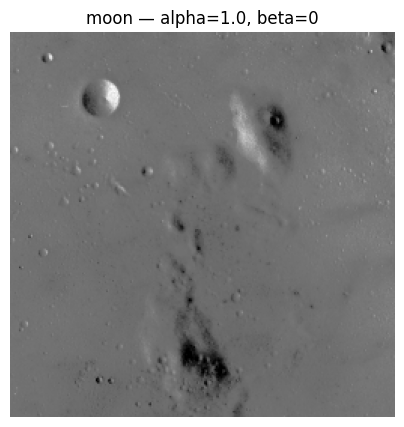

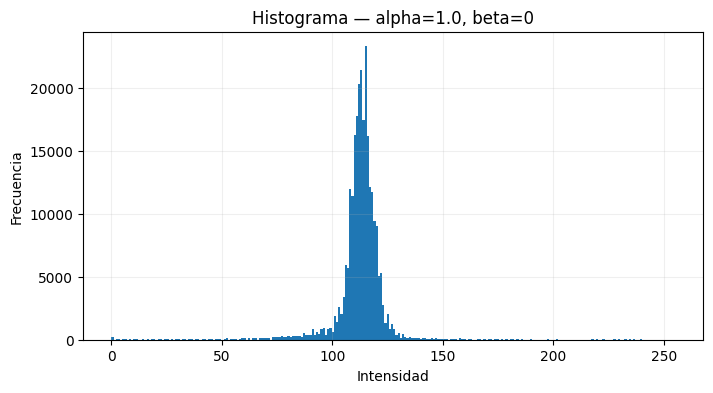

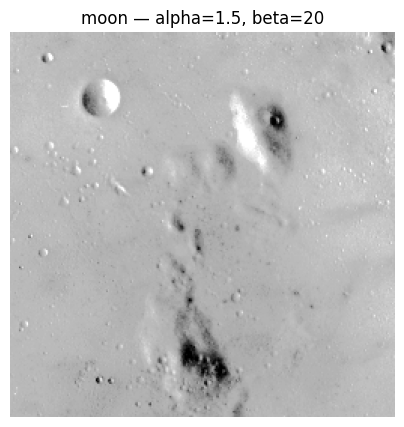

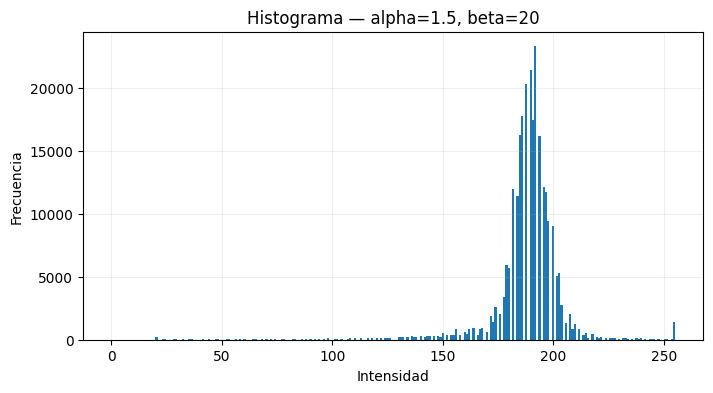

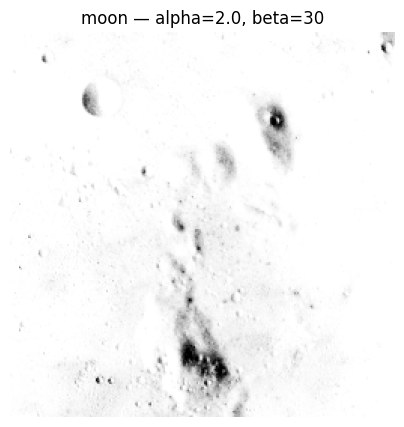

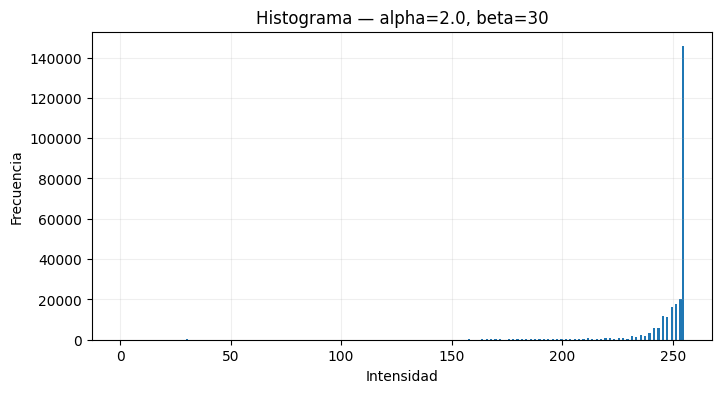

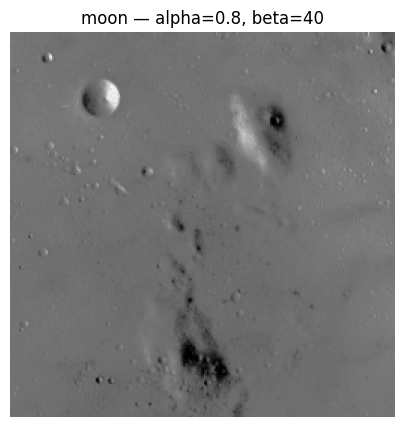

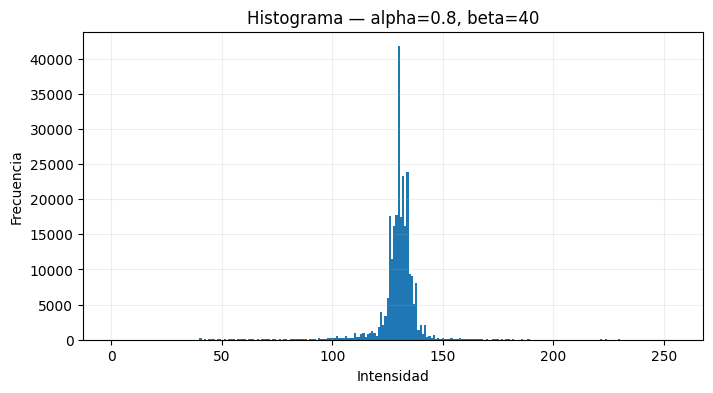

In [ ]:
img = images["moon"]

configs = [
    (1.0, 0),
    (1.5, 20),
    (2.0, 30),
    (0.8, 40)
]

for alpha, beta in configs:
    adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    show_gray(adjusted, f"moon — alpha={alpha}, beta={beta}")
    plot_histogram(adjusted, f"Histograma — alpha={alpha}, beta={beta}")


## Preguntas

1. ¿Qué ocurre cuando aumenta `alpha`?
2. ¿Qué ocurre cuando aumenta `beta`?
3. ¿Puede una imagen quedar “quemada”? ¿Cómo se observa en el histograma?

### Respuesta del alumno

1R=/ Aumentar alfa actua aclarando los tonos claros y oscureciendo tonos oscuros.
2R=/ Aumentar beta, aumenta el brillo aclarando la imagen.
3R=/ Si, Se acumulan muchos valores a la derecha y desaparecen los de la izquierda.

# Ejercicio 3 — Ecualización normal y adaptativa

## Enunciado

Aplica ecualización global y ecualización adaptativa CLAHE sobre `moon` y `camera`.

## Se pide

1. Aplicar ecualización normal.
2. Aplicar ecualización adaptativa CLAHE.
3. Comparar los resultados visualmente.
4. Comparar histogramas.


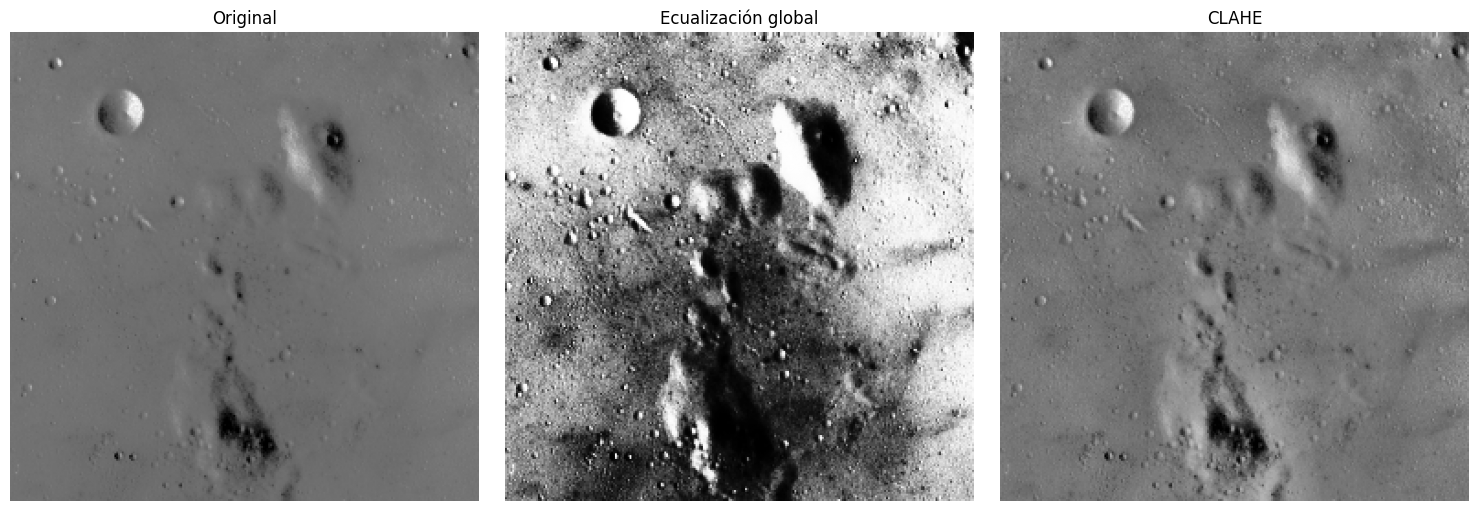

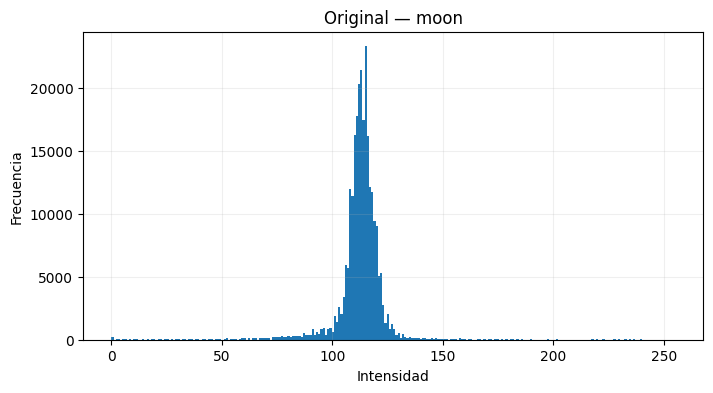

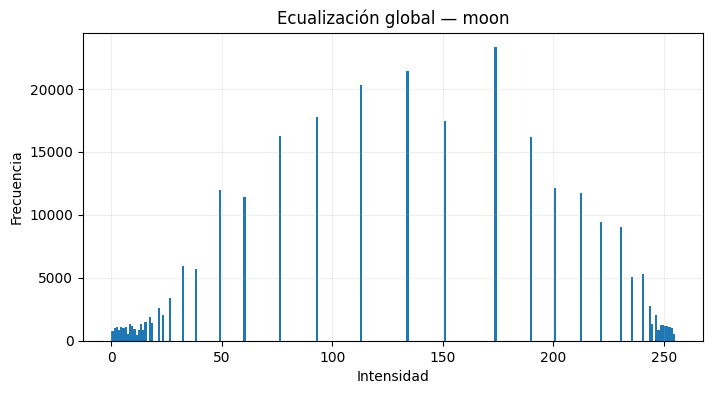

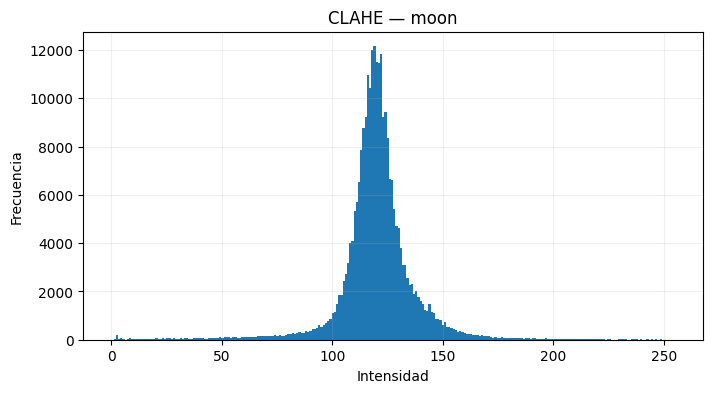

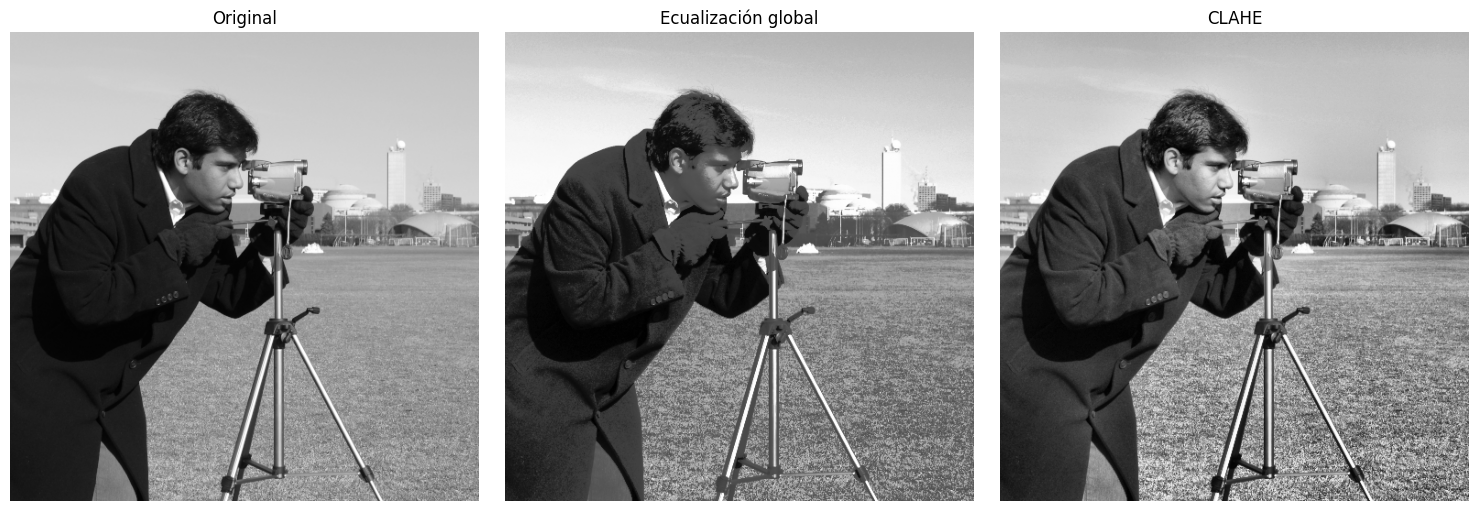

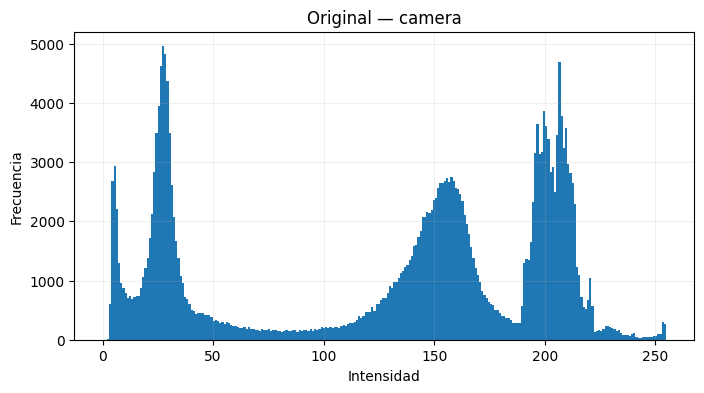

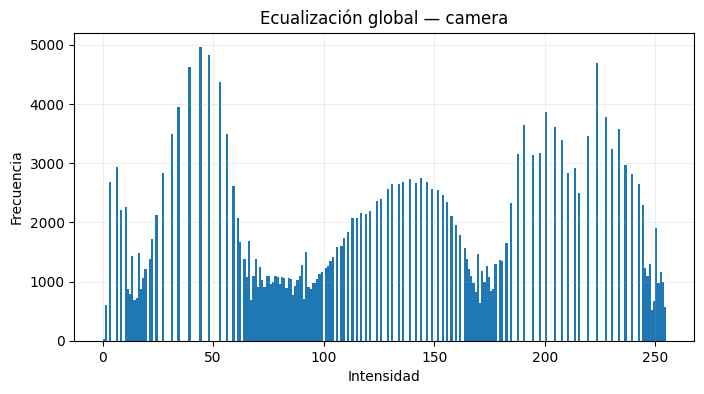

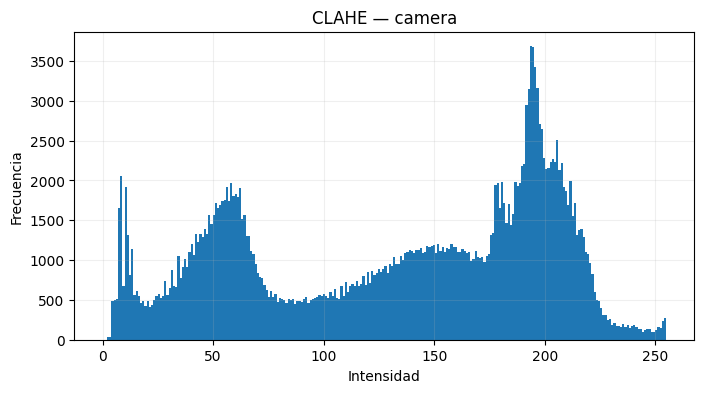

In [ ]:
for name in ["moon", "camera"]:
    img = images[name]

    equalized = cv2.equalizeHist(img)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(img)

    compare_images({
        "Original": img,
        "Ecualización global": equalized,
        "CLAHE": clahe_img
    }, cmap="gray", figsize=(15, 5))

    plot_histogram(img, f"Original — {name}")
    plot_histogram(equalized, f"Ecualización global — {name}")
    plot_histogram(clahe_img, f"CLAHE — {name}")


## Preguntas

1. ¿Qué diferencia hay entre ecualización global y CLAHE?
2. ¿En qué casos puede ser más útil CLAHE?
3. ¿Puede CLAHE amplificar ruido?

### Respuesta del alumno

1R=/La ecualización global genera una imagen mas contrastada delimitando mejor las areas claras de las oscuras. La CLAHE mejora el contraste en zonas mas pequeñas, no toma la imagen como un todo generando transiciones mas suaves y naturales.
2R=/CLAHE permite detalles mas suaves y mejor balance de colores.
3R=/ Si, pero lo controla mejor que la ecualización global, porque maneja el contraste de manera local.


# Ejercicio 4 — Convoluciones y filtros

## Enunciado

Aplica distintos filtros sobre la imagen `camera`.

## Filtros a utilizar

- Filtro de media.
- Filtro de mediana.
- Filtro paso alto.
- Sobel X.
- Sobel Y.
- Sobel combinado.
- Laplace.

## Se pide

1. Aplicar cada filtro.
2. Mostrar resultados.
3. Explicar qué tipo de información resalta o elimina cada uno.


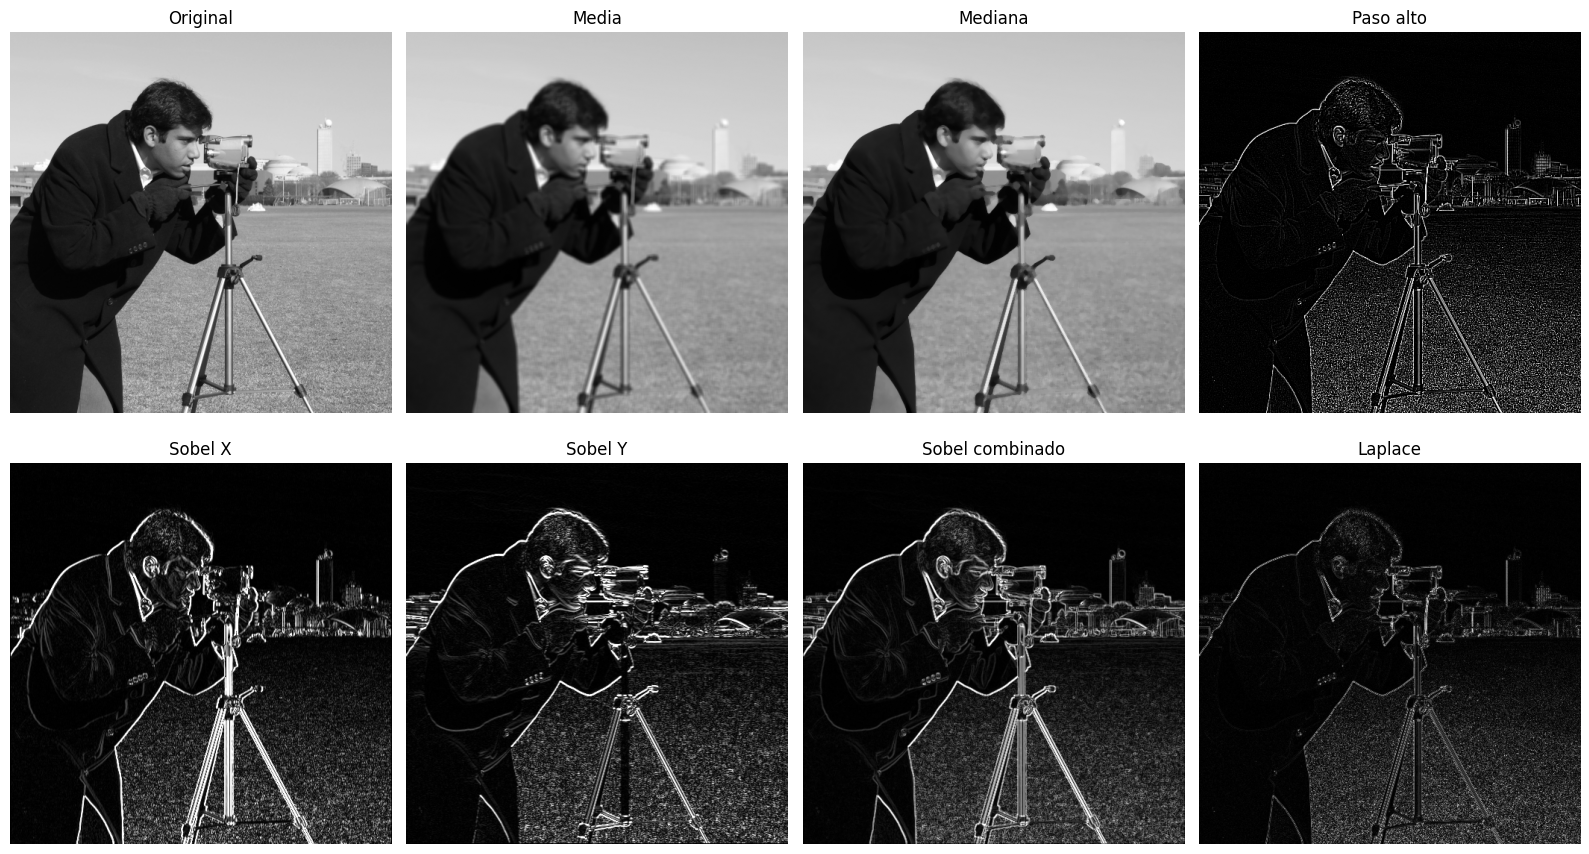

In [ ]:
img = images["camera"]

mean_filter = cv2.blur(img, (5, 5))
median_filter = cv2.medianBlur(img, 5)

high_pass_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])
high_pass = cv2.filter2D(img, -1, high_pass_kernel)

sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)

sobel_combined = cv2.addWeighted(sobel_x_abs, 0.5, sobel_y_abs, 0.5, 0)

laplace = cv2.Laplacian(img, cv2.CV_64F)
laplace_abs = cv2.convertScaleAbs(laplace)

results = {
    "Original": img,
    "Media": mean_filter,
    "Mediana": median_filter,
    "Paso alto": high_pass,
    "Sobel X": sobel_x_abs,
    "Sobel Y": sobel_y_abs,
    "Sobel combinado": sobel_combined,
    "Laplace": laplace_abs
}

plt.figure(figsize=(16, 9))

for i, (title, result) in enumerate(results.items(), start=1):
    plt.subplot(2, 4, i)
    plt.imshow(result, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Preguntas

1. ¿Qué filtro suaviza más la imagen?
2. ¿Qué filtro conserva mejor los bordes?
3. ¿Qué diferencia observas entre Sobel X y Sobel Y?
4. ¿Qué detecta mejor Laplace?
5. ¿Qué ocurre si aplicas un filtro paso alto sobre una imagen con ruido?

### Respuesta del alumno

1R=/Media.
2R=/Mediana.
3R=/En sobel Y se pierden bordes profundos y en sobel X lo opuesto.
4R=/ Mantiene la presepción de profundidad y el contraste natural de las siluetas.
5R=/ El filtro resalta el ruido.

# Ejercicio 5 — Umbralización simple, Otsu y adaptativa

## Enunciado

Segmenta la imagen `page`, que contiene texto y variaciones de iluminación.

## Se pide

1. Aplicar umbralización simple.
2. Aplicar Otsu.
3. Aplicar umbralización adaptativa.
4. Comparar los resultados.


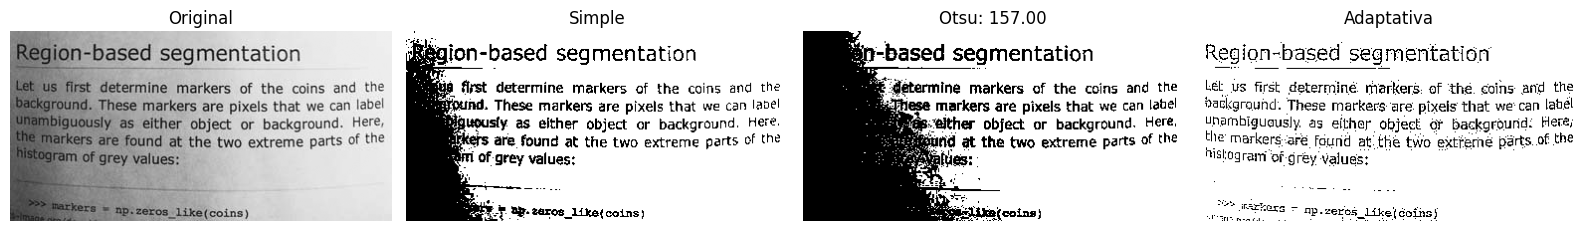

In [ ]:
img = images["page"]

_, thresh_simple = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

otsu_value, thresh_otsu = cv2.threshold(
    img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

thresh_adaptive = cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    3,
    11
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(thresh_simple, cmap="gray")
plt.title("Simple")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(thresh_otsu, cmap="gray")
plt.title(f"Otsu: {otsu_value:.2f}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(thresh_adaptive, cmap="gray")
plt.title("Adaptativa")
plt.axis("off")

plt.tight_layout()
plt.show()


## Preguntas

1. ¿Por qué la umbralización simple falla en algunas zonas?
2. ¿Qué calcula Otsu automáticamente?
3. ¿Por qué la umbralización adaptativa suele funcionar mejor en documentos?
4. Cambia el parámetro `blockSize` de la umbralización adaptativa. ¿Qué ocurre?

### Respuesta del alumno

1R=/ porque divide negro y blanco y agrupa todo en esos dos componentes.
2R=/ El threshold de umbralización entre negro y blanco.
3R=/ Por que se aplica por regiones y permite mejor la interaccion entre los cambios de iluminacion y detalles del fondo y la letra.
4R=/ Al subirlo se empezaron a hacer mas difusas las letras tomando el blanco poder y al bajarlo aparecen puntos negros.

# Ejercicio 6 — Componentes conexas y bounding boxes

## Enunciado

Detecta objetos en la imagen `coins`.

## Se pide

1. Convertir la imagen a binaria.
2. Detectar componentes conexas.
3. Dibujar bounding boxes sobre los objetos.
4. Filtrar componentes pequeñas que sean ruido.


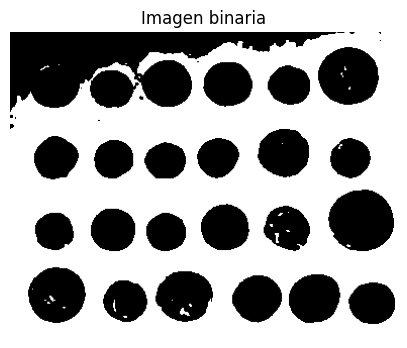

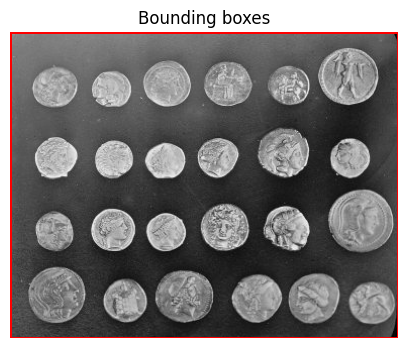

Número de componentes detectadas sin contar el fondo: 27


In [ ]:
img = images["coins"]

blur = cv2.GaussianBlur(img, (5, 5), 0)

_, binary = cv2.threshold(
    blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binary, connectivity=8
)

output = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

min_area = 100

for i in range(1, num_labels):
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    if area >= min_area:
        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(
            output,
            str(i),
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1
        )

show_gray(binary, "Imagen binaria")
show(output, "Bounding boxes")
print("Número de componentes detectadas sin contar el fondo:", num_labels - 1)


## Preguntas

1. ¿Por qué se ignora la etiqueta 0?
2. ¿Qué representa `stats`?
3. ¿Por qué conviene filtrar por área?
4. ¿Qué pasa si usamos conectividad 4 en lugar de 8?

### Respuesta del alumno

1R=/ El cero es el fondo.
2R=/ Las propiedades de cada componente detectado.
3R=/ El filtro por area ayuda a ubicar mejor los componentes detectando mejor ruido o manchas.
4R=/ 4 arriba abajo derecha izquierda, 8 las mismas que cuatro pero tambien en diagonal. 4 detecta 28, con 8 se detectarian en este caso menos componenetes.

# Ejercicio 7 — Algoritmo de dos pasadas

## Enunciado

Implementa una versión simplificada del algoritmo de etiquetado de componentes conexas con dos pasadas.

Trabajaremos sobre una imagen binaria pequeña generada manualmente.

## Se pide

1. Etiquetar los píxeles activos.
2. Resolver equivalencias.
3. Comparar la salida con `cv2.connectedComponents`.


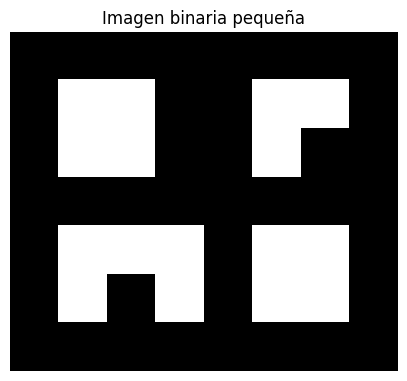

[[0 0 0 0 0 0 0 0]
 [0 1 1 0 0 1 1 0]
 [0 1 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 0]
 [0 1 1 1 0 1 1 0]
 [0 1 0 1 0 1 1 0]
 [0 0 0 0 0 0 0 0]]


In [ ]:
binary_small = np.array([
    [0,0,0,0,0,0,0,0],
    [0,1,1,0,0,1,1,0],
    [0,1,1,0,0,1,0,0],
    [0,0,0,0,0,0,0,0],
    [0,1,1,1,0,1,1,0],
    [0,1,0,1,0,1,1,0],
    [0,0,0,0,0,0,0,0]
], dtype=np.uint8)

show_gray(binary_small, "Imagen binaria pequeña")
print(binary_small)


[[0 0 0 0 0 0 0 0]
 [0 1 1 0 0 2 2 0]
 [0 1 1 0 0 2 0 0]
 [0 0 0 0 0 0 0 0]
 [0 3 3 3 0 4 4 0]
 [0 3 0 3 0 4 4 0]
 [0 0 0 0 0 0 0 0]]


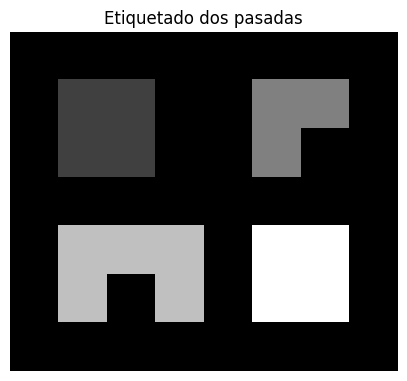

In [ ]:
def find(parent, x):
    while parent[x] != x:
        x = parent[x]
    return x

def union(parent, a, b):
    root_a = find(parent, a)
    root_b = find(parent, b)
    if root_a != root_b:
        parent[root_b] = root_a

def two_pass_labeling(binary):
    h, w = binary.shape
    labels = np.zeros((h, w), dtype=np.int32)

    current_label = 1
    parent = {}

    # Primera pasada
    for i in range(h):
        for j in range(w):
            if binary[i, j] == 0:
                continue

            neighbors = []

            # vecino superior
            if i > 0 and labels[i - 1, j] > 0:
                neighbors.append(labels[i - 1, j])

            # vecino izquierdo
            if j > 0 and labels[i, j - 1] > 0:
                neighbors.append(labels[i, j - 1])

            if len(neighbors) == 0:
                labels[i, j] = current_label
                parent[current_label] = current_label
                current_label += 1
            else:
                min_label = min(neighbors)
                labels[i, j] = min_label

                for lab in neighbors:
                    union(parent, min_label, lab)

    # Segunda pasada
    for i in range(h):
        for j in range(w):
            if labels[i, j] > 0:
                labels[i, j] = find(parent, labels[i, j])

    return labels

labels_two_pass = two_pass_labeling(binary_small)

print(labels_two_pass)
show_gray(labels_two_pass, "Etiquetado dos pasadas")


[[0 0 0 0 0 0 0 0]
 [0 1 1 0 0 2 2 0]
 [0 1 1 0 0 2 0 0]
 [0 0 0 0 0 0 0 0]
 [0 3 3 3 0 4 4 0]
 [0 3 0 3 0 4 4 0]
 [0 0 0 0 0 0 0 0]]


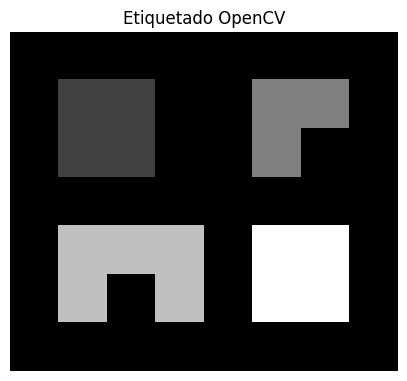

Número de componentes según OpenCV: 4


In [ ]:
num_labels_cv, labels_cv = cv2.connectedComponents(binary_small, connectivity=4)

print(labels_cv)
show_gray(labels_cv, "Etiquetado OpenCV")
print("Número de componentes según OpenCV:", num_labels_cv - 1)


## Preguntas

1. ¿Por qué hacen falta dos pasadas?
2. ¿Qué son las equivalencias entre etiquetas?
3. ¿Qué diferencia habría con conectividad 8?
4. ¿Por qué OpenCV puede devolver números de etiqueta distintos aunque las regiones sean las mismas?

### Respuesta del alumno

1R=/ El algoritmo hace la primera pasada asignando etiquetas temporales.
2R=/ Indican que dos etiquetas estan conectadas al mismo objeto.
3R=/ Tambien se considerarian conectados los pixeles diagonales entonces menos componentes.
4R=/ Porque el numero de etiquetas lo que representa es como el algoritmo detecta las regiones, no los componentes reales en si mismos.

# Ejercicio 8 — Filtrado morfológico

## Enunciado

Aplica operaciones morfológicas sobre una imagen binaria obtenida a partir de `coins`.

## Se pide

Aplicar:

- erosión,
- dilatación,
- apertura,
- cierre,
- extracción de fronteras,
- filtro min,
- filtro max.


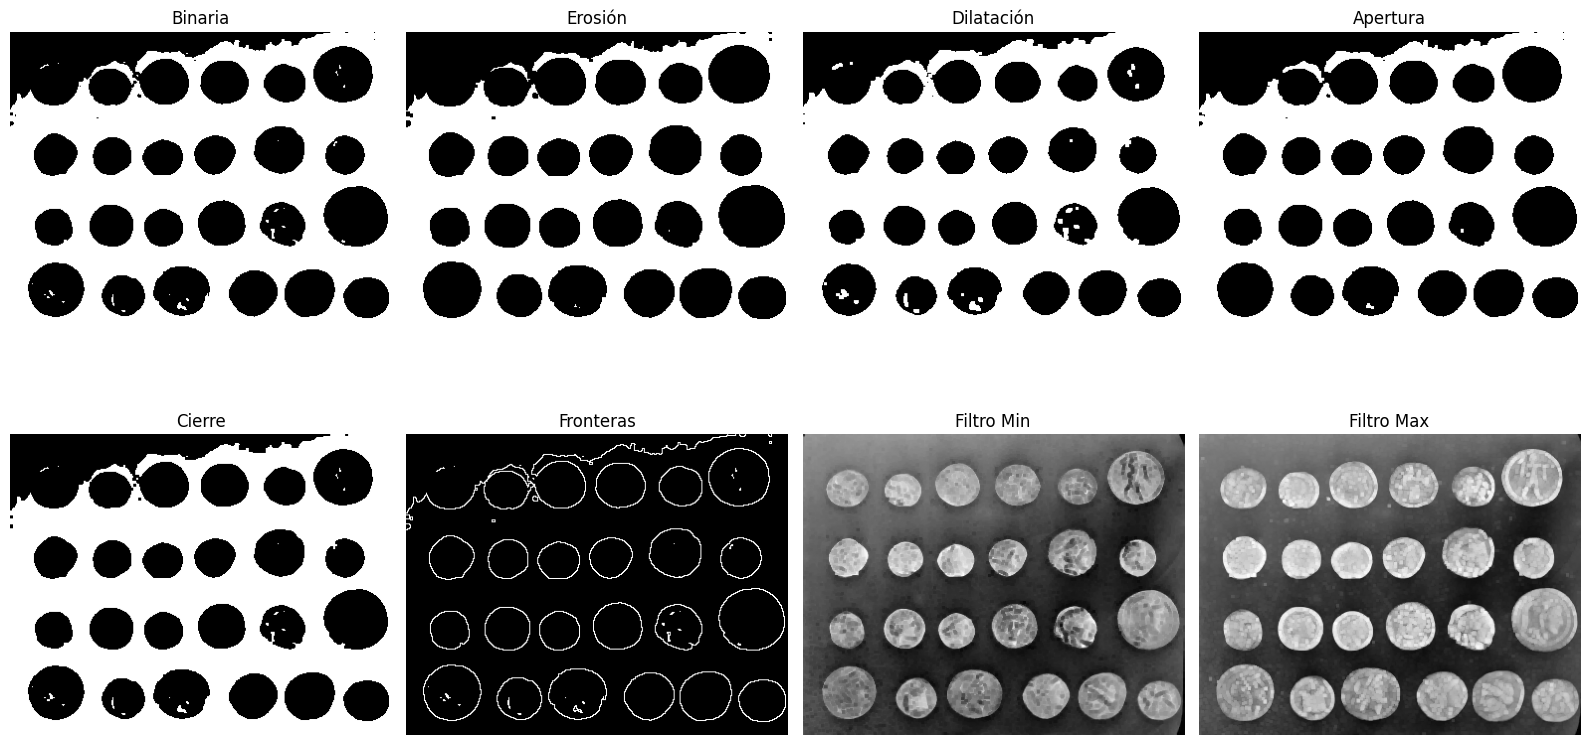

In [ ]:
img = images["coins"]

blur = cv2.GaussianBlur(img, (5, 5), 0)

_, binary = cv2.threshold(
    blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((3, 3), np.uint8)

erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)

opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

boundary = binary - erosion

min_filter = cv2.erode(img, kernel)
max_filter = cv2.dilate(img, kernel)

results = {
    "Binaria": binary,
    "Erosión": erosion,
    "Dilatación": dilation,
    "Apertura": opening,
    "Cierre": closing,
    "Fronteras": boundary,
    "Filtro Min": min_filter,
    "Filtro Max": max_filter
}

plt.figure(figsize=(16, 9))

for i, (title, result) in enumerate(results.items(), start=1):
    plt.subplot(2, 4, i)
    plt.imshow(result, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Preguntas

1. ¿Qué efecto produce la erosión sobre los objetos blancos?
2. ¿Qué efecto produce la dilatación?
3. ¿Para qué sirve la apertura?
4. ¿Para qué sirve el cierre?
5. ¿Por qué la extracción de fronteras puede obtenerse como `imagen - erosión`?
6. ¿Qué relación hay entre filtro min/max y morfología en escala de grises?

### Respuesta del alumno

1R=/ Reduce el tamaño de los objetos blancos.
2R=/ El opuesto a la erosión, los aumenta.
3R=/ Elimina ruido pequeño y separa objetos ligeramente conectados.
4R=/ Une regiones cercanas y suaviza contornos.
5R=/ Asi se eliminan los pixeles de los bordes.
6R=/ En escala de grises el filtro min erosiona y el max dilata.

# Ejercicio 9 — Hit and Miss

## Enunciado

Aplica `hit and miss` sobre una imagen binaria pequeña para detectar patrones concretos.

## Se pide

1. Crear una imagen binaria simple.
2. Definir un kernel con valores `1`, `0` y `-1`.
3. Detectar el patrón.
4. Interpretar el resultado.


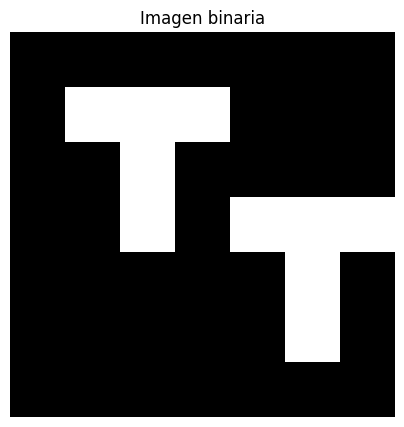

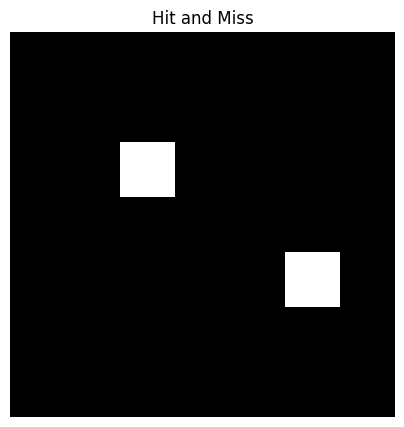

Resultado Hit and Miss:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


In [ ]:
binary_pattern = np.array([
    [0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0],
    [0,0,1,0,0,0,0],
    [0,0,1,0,1,1,1],
    [0,0,0,0,0,1,0],
    [0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0]
], dtype=np.uint8)

kernel_hitmiss = np.array([
    [ 0,  1,  0],
    [ 0,  1,  0],
    [ 0,  1,  0]
], dtype=np.int8)

hitmiss = cv2.morphologyEx(
    binary_pattern,
    cv2.MORPH_HITMISS,
    kernel_hitmiss
)

show_gray(binary_pattern, "Imagen binaria")
show_gray(hitmiss, "Hit and Miss")
print("Resultado Hit and Miss:")
print(hitmiss)


## Preguntas

1. ¿Qué patrón está buscando el kernel?
2. ¿Qué significa el valor `-1` dentro del kernel?
3. ¿En qué se diferencia `hit and miss` de la erosión?
4. Modifica el kernel para buscar una línea horizontal de 3 píxeles.

### Respuesta del alumno

1R=/ Busca una linea vertical negra.
2R=/ Que no importan esas dos posiciones, pueden tener cualquier valor.
3R=/ Hit and miss busca patrones exactos en la erosion solo se reduce el patron al eliminar los bordes es decir solo permite los unos del centro.

# Ejercicio 10 — Pipeline libre final

## Enunciado

Elige una de las cinco imágenes y construye un pipeline completo de procesamiento clásico.

## Se pide

Tu pipeline debe incluir al menos:

1. Análisis de histograma.
2. Ajuste de brillo/contraste o ecualización.
3. Algún filtro de convolución.
4. Alguna técnica de umbralización.
5. Alguna operación morfológica.
6. Una conclusión final.

## Preguntas finales

1. ¿Qué problema principal tenía la imagen?
2. ¿Qué técnica produjo la mayor mejora?
3. ¿Qué técnica empeoró el resultado?
4. ¿Qué limitaciones has encontrado?
5. ¿Cómo cambiaría el enfoque si usáramos Deep Learning?


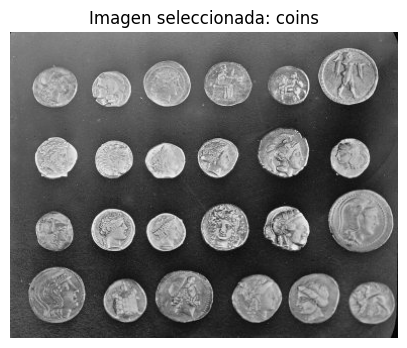

In [ ]:
# Espacio para el pipeline libre del alumno

selected_name = "coins"
img = images[selected_name]

if img.ndim == 2:
    gray = img
else:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

show_gray(gray, f"Imagen seleccionada: {selected_name}")

# TODO:
# 1. Analizar histograma
# 2. Mejorar contraste
# 3. Aplicar filtros
# 4. Umbralizar
# 5. Aplicar morfología
# 6. Mostrar resultado final


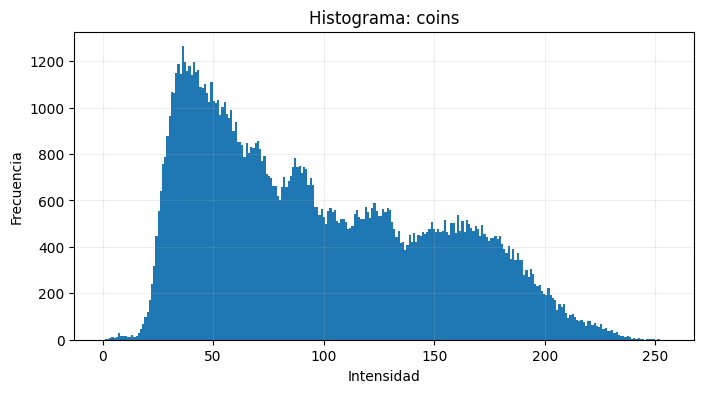

In [ ]:
    plot_histogram(img, f"Histograma: {selected_name}")

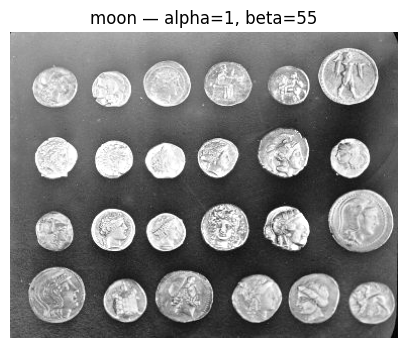

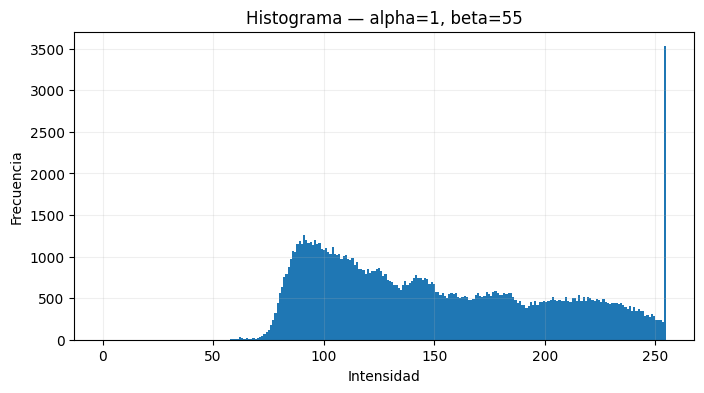

In [ ]:
alpha = 1
beta = 55
adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
show_gray(adjusted, f"moon — alpha={alpha}, beta={beta}")
plot_histogram(adjusted, f"Histograma — alpha={alpha}, beta={beta}")

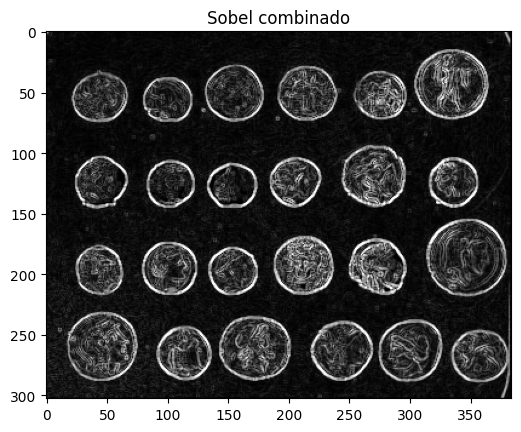

In [ ]:
sobel_x = cv2.Sobel(adjusted, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(adjusted, cv2.CV_64F, 0, 1, ksize=3)
sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)
sobel_combined = cv2.addWeighted(sobel_x_abs, 0.5, sobel_y_abs, 0.5, 0)

plt.imshow(sobel_combined, cmap="gray")
plt.title("Sobel combinado")
plt.show()

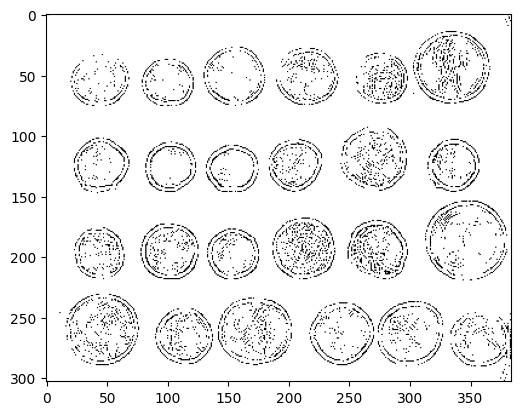

In [ ]:
thresh_adaptive = cv2.adaptiveThreshold(
    sobel_combined,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    5,
    35
)
plt.imshow(thresh_adaptive, cmap="gray")
plt.show()

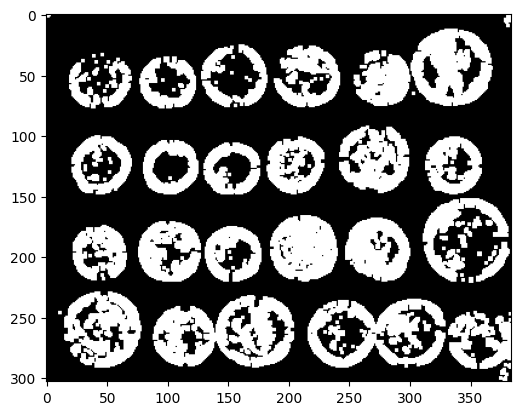

In [ ]:
blur = cv2.GaussianBlur(thresh_adaptive, (5, 5), 0)

_, binary = cv2.threshold(
    blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
kernel = np.ones((3, 3), np.uint8)
erosion = cv2.erode(binary, kernel, iterations=1)
# dilation = cv2.dilate(binary, kernel, iterations=1)
plt.imshow(dilation, cmap="gray")
plt.show()

# Entrega

Cada alumno deberá entregar este notebook completado con:

1. Código ejecutado.
2. Imágenes resultantes.
3. Histogramas.
4. Comparaciones visuales.
5. Respuestas razonadas a las preguntas.
6. Conclusión final.

# Rúbrica

| Apartado | Peso |
|---|---:|
| Carga y visualización correcta | 10% |
| Histogramas y análisis | 15% |
| Brillo, contraste y ecualización | 15% |
| Convoluciones y filtros | 20% |
| Umbralización | 15% |
| Componentes conexas y bounding boxes | 15% |
| Morfología matemática | 10% |
